# GSK_HepG2 ablation: metric vs training-data fraction

Pulls the single run from the `ablation_gsk_hepg2` wandb project, recovers the per-(fraction, model) rows from its history, and plots one line per model.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and pivot on the `model` column ourselves.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_PREFIX = "gsk_hepg2_data_fraction"
RUN_NAME = None  # set to an exact run name to pin a specific run; otherwise use the latest
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_roc_auc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
if RUN_NAME is not None:
    run = next(r for r in runs if r.name == RUN_NAME)
else:
    # Runs are named '<prefix>_<timestamp>'; pick the most recent matching run.
    matches = [r for r in runs if r.name.startswith(RUN_PREFIX)]
    run = max(matches, key=lambda r: r.created_at)
run.name, run.id

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/rahul/.netrc.


('gsk_hepg2_data_fraction_20260622_002225', '79yc4laa')

In [2]:
# Full, unsampled history -> one row per (fraction, model, seed).
df = pd.DataFrame(run.scan_history())
df = df[["fraction", "seed", "model", "n_train", METRIC]].sort_values(
    ["model", "fraction", "seed"]
)
df

,fraction,seed,model,n_train,test_average_precision
0,0.2,42,chemprop,2109,0.366372
10,0.2,53,chemprop,2109,0.401127
20,0.2,64,chemprop,2109,0.393843
30,0.2,75,chemprop,2109,0.422799
40,0.2,86,chemprop,2109,0.478212
2,0.4,42,chemprop,4212,0.391001
12,0.4,53,chemprop,4220,0.505898
22,0.4,64,chemprop,4218,0.502777
32,0.4,75,chemprop,4219,0.585545
42,0.4,86,chemprop,4217,0.477845


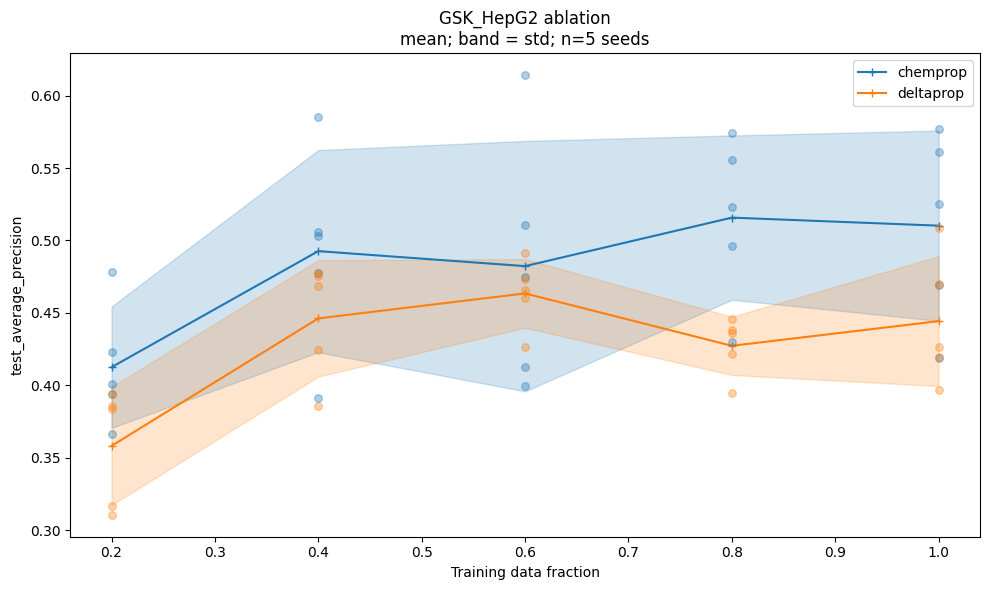

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

n_seeds = df["seed"].nunique()

# Aggregate across seeds: mean as a line, mean ± std as a shaded band, one per model.
# Raw per-seed points are overlaid so the spread stays visible.
for model, g in df.groupby("model"):
    agg = (
        g.groupby("fraction")[METRIC]
        .agg(
            mean="mean",
            std="std",
        )
        .reset_index()
        .sort_values("fraction")
    )
    (line,) = ax.plot(
        agg["fraction"],
        agg["mean"],
        marker="+",
        label=model,
    )
    color = line.get_color()
    ax.fill_between(
        agg["fraction"],
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        color=color,
        alpha=0.2,
    )
    # Raw per-seed points, so the spread (and any single strong seed) stays visible.
    ax.scatter(
        g["fraction"],
        g[METRIC],
        color=color,
        s=30,
        alpha=0.35,
        zorder=3,
    )

ax.set_xlabel("Training data fraction")
ax.set_ylabel(METRIC)
ax.set_title(f"GSK_HepG2 ablation\nmean; band = std; n={n_seeds} seeds")
ax.legend()
fig.tight_layout()
# fig.savefig("gsk_hepg2_ablation.png", dpi=150)
plt.show()